### Notebook for Testing Trained Models  
Cells are run sequentially:  
    **~ Cell 1**: Importing libraries, ensure correct filepath to the models.  
    **~ Cell 2**: Importing model, `seed_import` determines whether to import a seed model or regularly trained model,   
    ...then the specific run can be selected by with the corresponding index as the `run_number`, or specifying the seed run name.  
    **~ Cell 3**: Generate test data, parameters of the test data can be varied and distributions plotted.  
    **~ Cell 4**: Compute the Ricci tensors for the loaded model on the test data.  
    **~ Cell 5**: Plot visualisations of the loaded model metrics and computed Ricci tensors on the test data. Plotting parameters can be  
    ...edited, including setting the `plot_radial_limit` to reduce to the patch portions used for the global manifold definition.  
    **~ Cell 6**: Compute the Global test loss for the loaded model on the test data, printing components.  
    **~ Cell 7**: Plot visualisations of analytic metrics, either the identity initialisation or analytic round metric.  

In [1]:
# Import libraries
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

tf.keras.backend.set_floatx("float64")

# Import relevant functions
sys.path.append(os.path.abspath(os.getcwd() + "/../"))
from geometry.base import compute_kretschmann_scalar, compute_ricci_tensor
from geometry.ricci_opt import compute_ricci_and_kretschmann_embed_opt
from geometry.schwarzschild import (
    AnalyticMetric_R2S2,
    PatchChange_Coordinates_R2S2,
    PatchChange_Metric_R2S2,
    compute_ricci_and_kretschmann_embed,
    embed_S2_coords,
    embedding_jacobian_stereo,
)
from helper_functions.helper_functions import cholesky_from_vec, list_saved_models
from losses.schwarzschild import TotalSchwarzschildLoss
from network.schwarzschild import SchwarzschildGlobalModel, SchwarzschildPatchSubModel
from sampling.ball import BallSample, StereoSampleHemisphere
from sampling.penrose import PenroseSample, draw_penrose

# Output the list of saved models (to select which to import with in the following cell)
import_from_seed_models = True  # ...if True the seed models will be printed and importable, if False the trained models in runs are.
saved_models = list_saved_models(import_from_seed_models=import_from_seed_models)

Available models in seed_models:
0: IL_embed
1: AL_embed


In [2]:
# Import the model of interest
model_index = 0

# Build the model path
root_runs_path = os.path.join(
    os.getcwd(), "..", "seed_models" if import_from_seed_models else "runs"
)
if import_from_seed_models:
    # saved_runs entries are model names without '.keras'
    model_name = saved_models[model_index]
    model_path = os.path.join(root_runs_path, f"{model_name}.keras")
else:
    # saved_runs entries are run folder names
    run_folder = saved_models[model_index]
    model_path = os.path.join(root_runs_path, run_folder, "final_model.keras")
    # Alternative if importing a specific epoch:
    # epoch_number = 85
    # model_path = os.path.join(root_runs_path, run_folder, f"epoch_{epoch_number}_model.keras")

# Load the model
loaded_model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "GlobalModel": SchwarzschildGlobalModel,
        "PatchSubModel": SchwarzschildPatchSubModel,
    },
)

# Print the config items
for config_sublist in loaded_model.config:
    print(config_sublist)

2026-05-26 23:01:39.694692: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-26 23:01:39.694903: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-26 23:01:39.694917: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-26 23:01:39.695270: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-26 23:01:39.695313: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


('geometry', GeometryConfig(dim=4, n_patches=1, overlap_upperwidth=0.1, einstein_constant=0.0))
('data', DataConfig(patch_width=None, num_samples=10000))
('loss', SchwarzschildLossConfig(einstein_multiplier=1.0, overlap_multiplier=0.0, finiteness_multiplier=0.0, einstein_schedule=None, overlap_schedule=None, finiteness_schedule=None, kretschmann_schedule=None, r2_det_schedule=None, petrov_schedule=None))
('model', ModelConfig(experiment='schwarzschild', saved_model=False, saved_model_path='seed_models/IL_embed.keras', n_hidden=128, n_layers=4, activations='gelu', use_bias=True, np_seed=1556370813, tf_seed=4142775966, dtype='float64'))
('training', TrainingConfig(epochs=50, batch_size=256, init_learning_rate=0.003, min_learning_rate=0.003, use_validation=True, val_print=False, num_val_samples=200, val_batch_size=100, verbosity=1))
('finiteness', FinitenessConfig(finite_centre=140.0, finite_width=160.0, finite_sharpness=8.0, finite_height=100.0, finite_slope=0.2))
('logging', LoggingConf

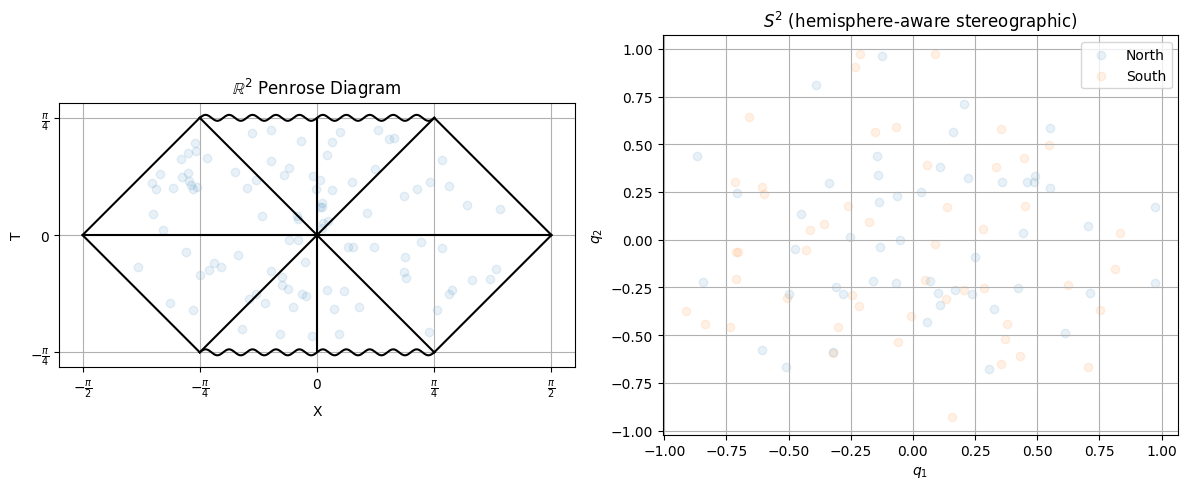

In [ ]:
# Compatibility aliases – set here, used throughout the notebook
n_patches = loaded_model.config.geometry.n_patches
embed = getattr(loaded_model.config.model_specific, "embed", False)
lorentzian = getattr(loaded_model.config.model_specific, "lorentzian", True)

# Define the test sample hyperparameters and generate it
num_samples = int(300)
patch_width_R2 = 0.85  # loaded_model.config.model_specific.patch_width_R2
patch_width_S2 = loaded_model.config.model_specific.patch_width_S2
density_power_R2 = 0.8  # loaded_model.config.model_specific.density_power_R2
density_power_S2 = loaded_model.config.model_specific.density_power_S2

if embed:
    # S^2-embedding architecture: single 5D sample [T, X, q1, q2, patch_idx]
    test_sample_R2 = PenroseSample(
        num_samples, patch_width=patch_width_R2, density_power=density_power_R2
    )
    test_sample_S2, test_patch_idx = StereoSampleHemisphere(
        num_samples, patch_width=patch_width_S2, density_power=density_power_S2
    )
    patch_idx_col = test_patch_idx.reshape(-1, 1).astype(np.float64)
    test_samples = [
        tf.constant(
            np.concatenate([test_sample_R2, test_sample_S2, patch_idx_col], axis=1)
        )
    ]

    # Plot the sample
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].set_title(r"$\mathbb{R}^2$ Penrose Diagram")
    draw_penrose(axes[0])
    axes[0].scatter(test_sample_R2[:, 1], test_sample_R2[:, 0], alpha=0.1)
    axes[0].grid()
    north, south = test_patch_idx == 0, test_patch_idx == 1
    axes[1].set_title(r"$S^2$ (hemisphere-aware stereographic)")
    axes[1].scatter(
        test_sample_S2[north, 0], test_sample_S2[north, 1], alpha=0.1, label="North"
    )
    axes[1].scatter(
        test_sample_S2[south, 0], test_sample_S2[south, 1], alpha=0.1, label="South"
    )
    axes[1].set_xlabel(r"$q_1$")
    axes[1].set_ylabel(r"$q_2$")
    axes[1].legend()
    axes[1].grid()

elif n_patches == 2:
    # Two-patch stereographic architecture
    test_sample_S2 = BallSample(
        num_samples,
        dimension=2,
        patch_width=patch_width_S2,
        density_power=density_power_S2,
    )
    test_sample_R2 = PenroseSample(
        num_samples, patch_width=patch_width_R2, density_power=density_power_R2
    )
    test_samples = [tf.concat([test_sample_R2, test_sample_S2], axis=1)]
    test_samples.append(PatchChange_Coordinates_R2S2(test_samples[0]))

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    S2_axes_lim = 1.1
    axes[0].set_title(r"$\mathbb{R}^2$ Penrose Diagram")
    draw_penrose(axes[0])
    axes[0].grid()
    axes[0].scatter(test_sample_R2[:, 1], test_sample_R2[:, 0], alpha=0.1)
    for i in range(1, 3):
        axes[i].set_title(rf"$S^2$ Patch {i}")
        axes[i].scatter(test_sample_S2[:, 0], test_sample_S2[:, 1], alpha=0.1)
        axes[i].set_xlim(-S2_axes_lim, S2_axes_lim)
        axes[i].set_ylim(-S2_axes_lim, S2_axes_lim)
        axes[i].set_xlabel(r"$x_s$")
        axes[i].set_ylabel(r"$y_s$")
        axes[i].grid()

else:
    # S^2-only single-patch architecture
    test_sample_S2 = BallSample(
        num_samples,
        dimension=2,
        patch_width=patch_width_S2,
        density_power=density_power_S2,
    )
    test_samples = [test_sample_S2]
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.set_title("Patch 1")
    ax.scatter(test_samples[0][:, 0], test_samples[0][:, 1], alpha=0.1)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.grid()

plt.tight_layout()

In [4]:
# Predict the metric and the Ricci on the test sample
if embed:
    # Embed architecture: pull back the 5D ambient metric to 4D via the Jacobian
    x_5d_tf = tf.cast(test_samples[0], tf.float64)
    q_4d = x_5d_tf[:, :4]
    p_idx = tf.cast(x_5d_tf[:, 4], tf.int32)
    G_5d_vec = loaded_model.submodel.predict(embed_S2_coords(q_4d, p_idx))
    G_5d = cholesky_from_vec(G_5d_vec, lorentzian=lorentzian)  # (batch, 5, 5)
    J = embedding_jacobian_stereo(q_4d, p_idx)  # (batch, 5, 4)
    predicted_metrics = [tf.einsum("sAB,sAm,sBn->smn", G_5d, J, J).numpy()]

    # Use the optimised forward-mode Ricci kernel when configured.
    ricci_kernel = getattr(
        loaded_model.config.model_specific, "ricci_kernel", "standard"
    )
    ricci_fn = (
        compute_ricci_and_kretschmann_embed_opt
        if ricci_kernel == "optimised"
        else compute_ricci_and_kretschmann_embed
    )
    _, ricci_embed, _ = ricci_fn(
        x_5d_tf,
        loaded_model.submodel,
        lorentzian=lorentzian,
        need_ricci=True,
        need_kretschmann=False,
    )
    predicted_riccis = [ricci_embed.numpy()]
else:
    predicted_vielbeins = [
        loaded_model.patch_submodels[i].predict(test_samples[i])
        for i in range(n_patches)
    ]
    predicted_metrics = [
        cholesky_from_vec(predicted_vielbeins[i], lorentzian=lorentzian).numpy()
        for i in range(n_patches)
    ]
    predicted_riccis = [
        compute_ricci_tensor(test_samples[i], loaded_model.patch_submodels[i]).numpy()
        for i in range(n_patches)
    ]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [5]:
# Compute the Global test loss
metric_pred = loaded_model.predict(test_samples[0])

schw_loss_trainer = TotalSchwarzschildLoss(loaded_model.config)
whole_schw_loss = schw_loss_trainer.call(
    loaded_model, test_samples[0], metric_pred, return_constituents=True, val_print=True
)
print(whole_schw_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
(<tf.Tensor: shape=(), dtype=float64, numpy=0.029220563526476222>, {'einstein_loss': np.float64(0.06898523172743819), 'kretschmann_loss': np.float64(0.015965674126155568)})


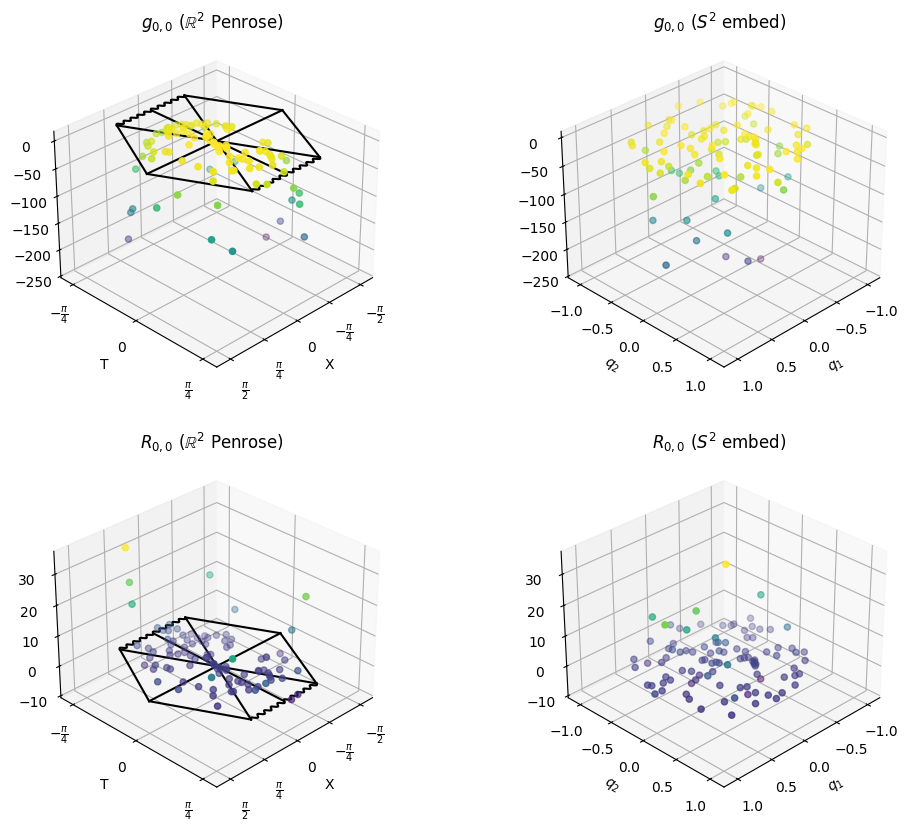

In [6]:
# Plotting: examine the trained metrics / ricci tensors
metric_index_1, metric_index_2 = 0, 0
plot_radial_limit = 1.0
save_pdf_filename = None

elevation_angle, azimuth_angle = 30, 45
if embed:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={"projection": "3d"})
elif n_patches == 1:
    fig, axes = plt.subplots(2, 1, figsize=(5, 10), subplot_kw={"projection": "3d"})
    axes = np.expand_dims(axes, -1)
else:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw={"projection": "3d"})

# Restrict plotted points to S^2 radial limit
if plot_radial_limit:
    s2_coords = lambda s: tf.cast(s[:, 2:4], tf.float64)
    if embed:
        mask = tf.norm(s2_coords(test_samples[0]), axis=-1) < plot_radial_limit
        test_samples_limited = [tf.boolean_mask(test_samples[0], mask)]
        predicted_metrics_limited = [tf.boolean_mask(predicted_metrics[0], mask)]
        predicted_riccis_limited = [tf.boolean_mask(predicted_riccis[0], mask)]
    else:
        masks = [
            tf.norm(s2_coords(test_samples[i]), axis=-1) < plot_radial_limit
            for i in range(n_patches)
        ]
        test_samples_limited = [
            tf.boolean_mask(test_samples[i], masks[i]) for i in range(n_patches)
        ]
        predicted_metrics_limited = [
            tf.boolean_mask(predicted_metrics[i], masks[i]) for i in range(n_patches)
        ]
        predicted_riccis_limited = [
            tf.boolean_mask(predicted_riccis[i], masks[i]) for i in range(n_patches)
        ]
else:
    test_samples_limited = test_samples
    predicted_metrics_limited = predicted_metrics
    predicted_riccis_limited = predicted_riccis


# ---------- Helper for plotting ----------
def plot_component(
    ax,
    x,
    y,
    z,
    values,
    title,
    xlab,
    ylab,
    xlim=None,
    ylim=None,
    elev=elevation_angle,
    azim=azimuth_angle,
):
    ax.scatter(x, y, z, c=values, cmap="viridis")
    ax.set_title(title)
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.view_init(elev=elev, azim=azim)


# ---------- Plotting ----------
def plot_all(axes_row, samples, values, symbol):
    z = values[0][:, metric_index_1, metric_index_2]
    if embed:
        plot_component(
            axes_row[0],
            samples[0][:, 1],
            samples[0][:, 0],
            z,
            z,
            rf"${symbol}_{{{metric_index_1},{metric_index_2}}}$ ($\mathbb{{R}}^2$ Penrose)",
            r"$X$",
            r"$T$",
            xlim=(
                -np.pi / 2 * 1.2 * plot_radial_limit,
                np.pi / 2 * 1.2 * plot_radial_limit,
            ),
            ylim=(
                -np.pi / 4 * 1.2 * plot_radial_limit,
                np.pi / 4 * 1.2 * plot_radial_limit,
            ),
        )
        draw_penrose(axes_row[0])
        plot_component(
            axes_row[1],
            samples[0][:, 2],
            samples[0][:, 3],
            z,
            z,
            rf"${symbol}_{{{metric_index_1},{metric_index_2}}}$ ($S^2$ embed)",
            r"$q_1$",
            r"$q_2$",
            xlim=(-1.2 * plot_radial_limit, 1.2 * plot_radial_limit),
            ylim=(-1.2 * plot_radial_limit, 1.2 * plot_radial_limit),
        )
    elif n_patches == 1:
        plot_component(
            axes_row[0],
            samples[0][:, 0],
            samples[0][:, 1],
            z,
            z,
            rf"${symbol}_{{{metric_index_1},{metric_index_2}}}$ Train (Single patch)",
            r"$x_1$",
            r"$x_2$",
            xlim=(-1.2 * plot_radial_limit, 1.2 * plot_radial_limit),
            ylim=(-1.2 * plot_radial_limit, 1.2 * plot_radial_limit),
        )
    else:
        for i in range(n_patches):
            z_i = values[i][:, metric_index_1, metric_index_2]
            ax_r2 = axes_row[2 * i]
            plot_component(
                ax_r2,
                samples[i][:, 1],
                samples[i][:, 0],
                z_i,
                z_i,
                rf"${symbol}_{{{metric_index_1},{metric_index_2}}}$ Train ($\mathbb{{R}}^2$ patch {i + 1})",
                r"$X$",
                r"$T$",
                xlim=(
                    -np.pi / 2 * 1.2 * plot_radial_limit,
                    np.pi / 2 * 1.2 * plot_radial_limit,
                ),
                ylim=(
                    -np.pi / 4 * 1.2 * plot_radial_limit,
                    np.pi / 4 * 1.2 * plot_radial_limit,
                ),
            )
            draw_penrose(ax_r2)
            ax_s2 = axes_row[2 * i + 1]
            plot_component(
                ax_s2,
                samples[i][:, 2],
                samples[i][:, 3],
                z_i,
                z_i,
                rf"${symbol}_{{{metric_index_1},{metric_index_2}}}$ Train ($S^2$ patch {i + 1})",
                r"$x_s$",
                r"$y_s$",
                xlim=(-1.2 * plot_radial_limit, 1.2 * plot_radial_limit),
                ylim=(-1.2 * plot_radial_limit, 1.2 * plot_radial_limit),
            )


plot_all(axes[0], test_samples_limited, predicted_metrics_limited, "g")
plot_all(axes[1], test_samples_limited, predicted_riccis_limited, "R")

if save_pdf_filename:
    plt.savefig(save_pdf_filename)

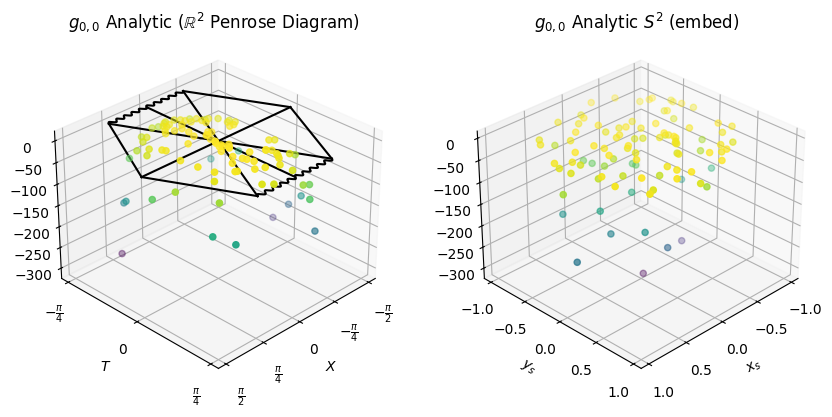

In [7]:
# Plot the analytic metrics with Penrose diagram
identity_bool = False
lorentzian_bool = True
metric_index_1, metric_index_2 = 0, 0

# Compute the analytic metrics on the test data
if embed:
    # Embed architecture: 5D samples — extract 4D coords for AnalyticMetric_R2S2
    coords_4d = test_samples[0][:, :4]
    analytic_metrics = [
        AnalyticMetric_R2S2(
            coords_4d, identity=identity_bool, lorentzian=lorentzian_bool
        )
    ]
    analytic_samples = [coords_4d]
elif identity_bool:
    analytic_metrics = [
        AnalyticMetric_R2S2(
            test_samples[patch_idx], identity=identity_bool, lorentzian=lorentzian_bool
        )
        for patch_idx in range(2)
    ]
    analytic_samples = [test_samples[0], test_samples[1]]
else:
    analytic_metrics = [
        AnalyticMetric_R2S2(
            test_samples[0], identity=identity_bool, lorentzian=lorentzian_bool
        )
    ]
    analytic_metrics.append(
        PatchChange_Metric_R2S2(test_samples[0], analytic_metrics[0])
    )
    analytic_samples = [test_samples[0], test_samples[1]]

# Setup the plots
elevation_angle, azimuth_angle = 30, 45
n_s2_plots = 1 if embed else 2
fig, axes = plt.subplots(
    1,
    1 + n_s2_plots,
    figsize=(5 * (1 + n_s2_plots), 5),
    subplot_kw={"projection": "3d"},
)

axes_lim = 1.1

# ---- R^2 plot with Penrose diagram ----
ax = axes[0]
ax.scatter(
    analytic_samples[0][:, 1],
    analytic_samples[0][:, 0],
    analytic_metrics[0][:, metric_index_1, metric_index_2],
    c=analytic_metrics[0][:, metric_index_1, metric_index_2],
    cmap="viridis",
)
draw_penrose(ax)
ax.set_title(
    rf"$g_{{{metric_index_1},{metric_index_2}}}$ Analytic ($\mathbb{{R}}^2$ Penrose Diagram)"
)
ax.set_xlim(-axes_lim * np.pi / 2, axes_lim * np.pi / 2)
ax.set_ylim(-axes_lim * np.pi / 4, axes_lim * np.pi / 4)
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$T$")
ax.view_init(elev=elevation_angle, azim=azimuth_angle)

# ---- S^2 plots ----
for i in range(n_s2_plots):
    ax = axes[i + 1]
    ax.scatter(
        analytic_samples[i][:, 2],
        analytic_samples[i][:, 3],
        analytic_metrics[i][:, metric_index_1, metric_index_2],
        c=analytic_metrics[i][:, metric_index_1, metric_index_2],
        cmap="viridis",
    )
    label = "embed" if embed else f"patch {i + 1}"
    ax.set_title(rf"$g_{{{metric_index_1},{metric_index_2}}}$ Analytic $S^2$ ({label})")
    ax.set_xlim(-axes_lim, axes_lim)
    ax.set_ylim(-axes_lim, axes_lim)
    ax.set_xlabel(r"$x_s$")
    ax.set_ylabel(r"$y_s$")
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

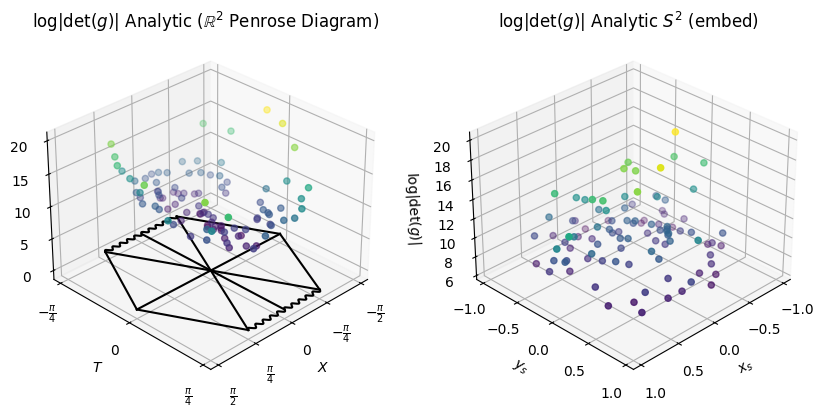

In [8]:
# Plot det(g) of the analytic metric with Penrose diagram
elevation_angle, azimuth_angle = 30, 45
n_s2_plots = 1 if embed else 2
fig, axes = plt.subplots(
    1,
    1 + n_s2_plots,
    figsize=(5 * (1 + n_s2_plots), 5),
    subplot_kw={"projection": "3d"},
)

axes_lim = 1.1

# Compute log|det| (3D axes don't support log scales natively)
analytic_dets = [
    tf.linalg.det(analytic_metrics[i]).numpy() for i in range(len(analytic_metrics))
]
analytic_log_dets = [np.log(np.abs(d)) for d in analytic_dets]

# ---- R^2 plot with Penrose diagram ----
ax = axes[0]
ax.scatter(
    analytic_samples[0][:, 1],
    analytic_samples[0][:, 0],
    analytic_log_dets[0],
    c=analytic_log_dets[0],
    cmap="viridis",
)
draw_penrose(ax)
ax.set_title(r"$\log|\det(g)|$ Analytic ($\mathbb{R}^2$ Penrose Diagram)")
ax.set_xlim(-axes_lim * np.pi / 2, axes_lim * np.pi / 2)
ax.set_ylim(-axes_lim * np.pi / 4, axes_lim * np.pi / 4)
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$T$")
ax.set_zlabel(r"$\log|\det(g)|$")
ax.view_init(elev=elevation_angle, azim=azimuth_angle)

# ---- S^2 plots ----
for i in range(n_s2_plots):
    ax = axes[i + 1]
    ax.scatter(
        analytic_samples[i][:, 2],
        analytic_samples[i][:, 3],
        analytic_log_dets[i],
        c=analytic_log_dets[i],
        cmap="viridis",
    )
    label = "embed" if embed else f"patch {i + 1}"
    ax.set_title(rf"$\log|\det(g)|$ Analytic $S^2$ ({label})")
    ax.set_xlim(-axes_lim, axes_lim)
    ax.set_ylim(-axes_lim, axes_lim)
    ax.set_xlabel(r"$x_s$")
    ax.set_ylabel(r"$y_s$")
    ax.set_zlabel(r"$\log|\det(g)|$")
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

(min,mean,max)
Patch 1: -332520488.0866566 -6162560.391117731 -699.1390784229869


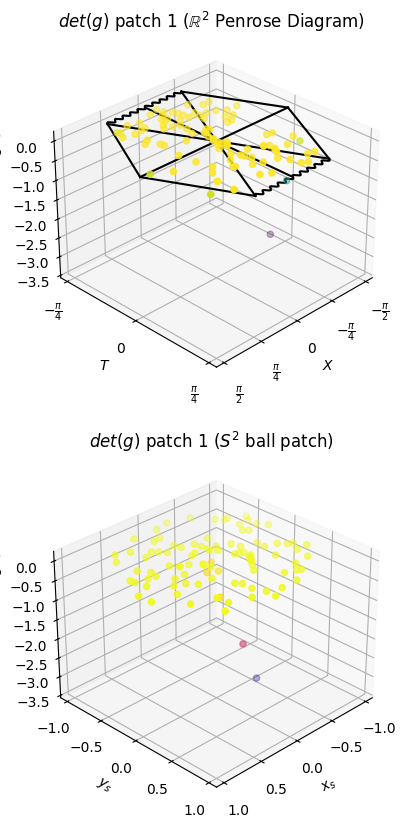

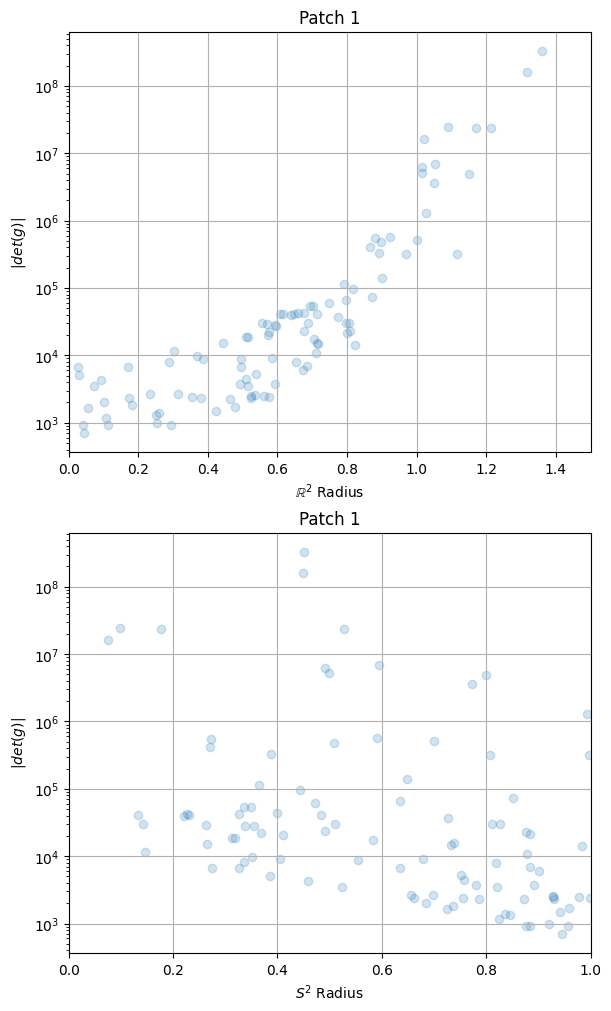

In [9]:
# Plot det(g) over the Penrose diagram
dets = [tf.linalg.det(predicted_metrics[i]) for i in range(n_patches)]

# Print det stats
for i in range(n_patches):
    print(
        f"(min,mean,max)\nPatch {i + 1}:",
        np.min(dets[i]),
        np.mean(dets[i]),
        np.max(dets[i]),
    )

# ---- R^2 plot with Penrose diagram ----
elevation_angle, azimuth_angle = 30, 45
fig, axes = plt.subplots(
    2, n_patches, figsize=(6 * n_patches, 10), subplot_kw={"projection": "3d"}
)
if n_patches == 1:
    axes = axes[:, np.newaxis]  # make consistent indexing
axes_lim = 1.1

for i in range(n_patches):
    ax = axes[0, i]
    ax.scatter(
        test_samples[i][:, 1],
        test_samples[i][:, 0],
        dets[i],
        c=dets[i],
        cmap="viridis",
    )
    draw_penrose(ax)
    ax.set_title(rf"$det(g)$ patch {i + 1} ($\mathbb{{R}}^2$ Penrose Diagram)")
    ax.set_xlim(-axes_lim * np.pi / 2, axes_lim * np.pi / 2)
    ax.set_ylim(-axes_lim * np.pi / 4, axes_lim * np.pi / 4)
    ax.set_xlabel(r"$X$")
    ax.set_ylabel(r"$T$")
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

for i in range(n_patches):
    ax = axes[1, i]
    ax.scatter(
        test_samples[i][:, 2],
        test_samples[i][:, 3],
        dets[i],
        c=dets[i],
        cmap="plasma",
    )
    ax.set_title(rf"$det(g)$ patch {i + 1} ($S^2$ ball patch)")
    ax.set_xlim(-axes_lim, axes_lim)
    ax.set_ylim(-axes_lim, axes_lim)
    ax.set_xlabel(r"$x_s$")
    ax.set_ylabel(r"$y_s$")
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

##################################################################################
# Plot against radius
fig, axes = plt.subplots(
    2, n_patches, figsize=(6 * n_patches, 10), constrained_layout=True
)
if n_patches == 1:
    axes = axes[:, np.newaxis]

for i in range(n_patches):
    radius_R2 = tf.sqrt(
        tf.square(test_samples[i][:, 0]) + tf.square(test_samples[i][:, 1])
    )
    axes[0, i].scatter(radius_R2, abs(dets[i]), alpha=0.2)
    axes[0, i].set_title(f"Patch {i + 1}")
    axes[0, i].set_xlabel(r"$\mathbb{R}^2$ Radius")
    axes[0, i].set_ylabel(r"$|det(g)|$")
    axes[0, i].set_xlim(0, 1.5)
    axes[0, i].set_yscale("log")
    axes[0, i].grid(True)

    radius_S2 = tf.sqrt(
        tf.square(test_samples[i][:, 2]) + tf.square(test_samples[i][:, 3])
    )
    axes[1, i].scatter(radius_S2, abs(dets[i]), alpha=0.2)
    axes[1, i].set_title(f"Patch {i + 1}")
    axes[1, i].set_xlabel(r"$S^2$ Radius")
    axes[1, i].set_ylabel(r"$|det(g)|$")
    axes[1, i].set_xlim(0, 1.0)
    axes[1, i].set_yscale("log")
    axes[1, i].grid(True)

# plt.savefig('|det(g)|.png')

(min,mean,max)
Patch 1: 0.012723642397742586 0.8353531102833226 4.89499279473302


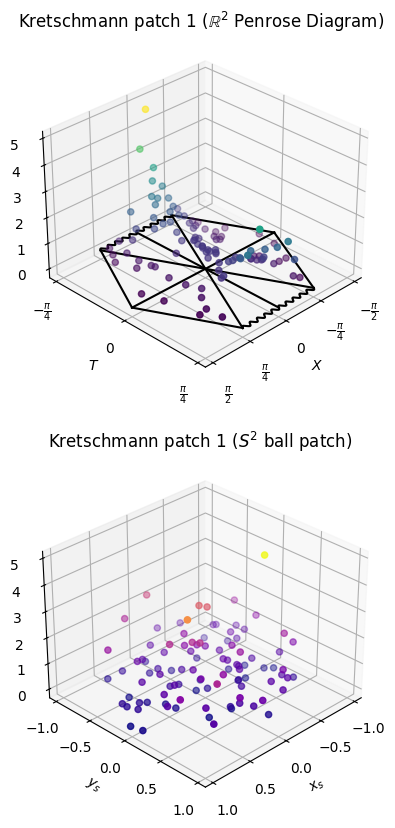

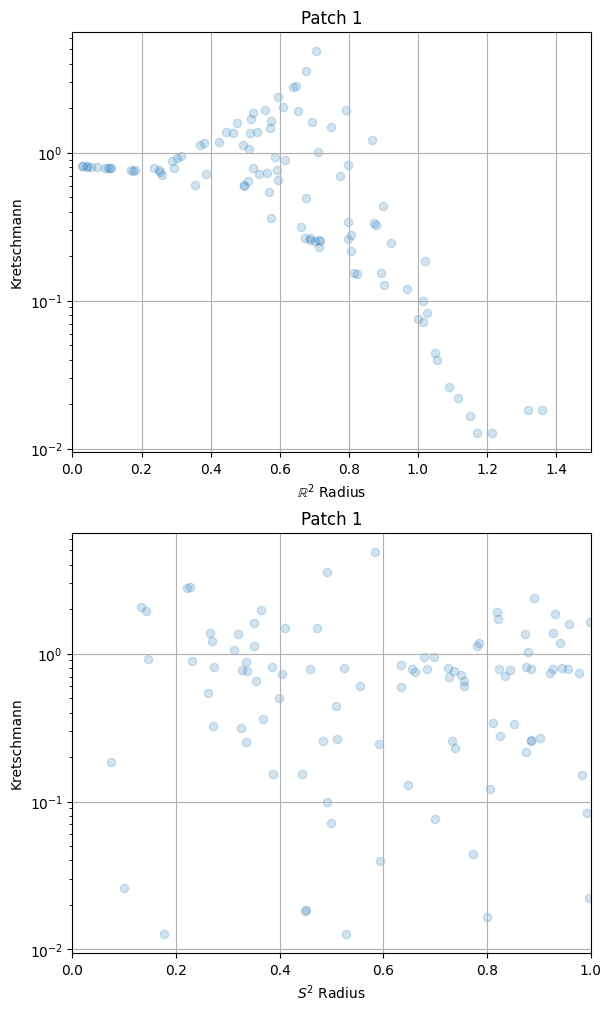

In [10]:
# Plot Kretschmann scalar over the Penrose diagram
if embed:
    ricci_kernel = getattr(
        loaded_model.config.model_specific, "ricci_kernel", "standard"
    )
    ricci_fn = (
        compute_ricci_and_kretschmann_embed_opt
        if ricci_kernel == "optimised"
        else compute_ricci_and_kretschmann_embed
    )
    _, _, k_embed = ricci_fn(
        tf.cast(test_samples[0], tf.float64),
        loaded_model.submodel,
        lorentzian=lorentzian,
        need_ricci=False,
        need_kretschmann=True,
    )
    Ks = [k_embed]
else:
    Ks = [
        compute_kretschmann_scalar(test_samples[i], loaded_model.patch_submodels[i])
        for i in range(n_patches)
    ]

# Print K stats
for i in range(n_patches):
    print(
        f"(min,mean,max)\nPatch {i + 1}:", np.min(Ks[i]), np.mean(Ks[i]), np.max(Ks[i])
    )

# ---- Spatial plots ----
elevation_angle, azimuth_angle = 30, 45
fig, axes = plt.subplots(
    2, n_patches, figsize=(6 * n_patches, 10), subplot_kw={"projection": "3d"}
)
if n_patches == 1:
    axes = axes[:, np.newaxis]
axes_lim = 1.1

for i in range(n_patches):
    ax = axes[0, i]
    ax.scatter(
        test_samples[i][:, 1],
        test_samples[i][:, 0],
        Ks[i],
        c=Ks[i],
        cmap="viridis",
    )
    draw_penrose(ax)
    ax.set_title(rf"Kretschmann patch {i + 1} ($\mathbb{{R}}^2$ Penrose Diagram)")
    ax.set_xlim(-axes_lim * np.pi / 2, axes_lim * np.pi / 2)
    ax.set_ylim(-axes_lim * np.pi / 4, axes_lim * np.pi / 4)
    ax.set_xlabel(r"$X$")
    ax.set_ylabel(r"$T$")
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

for i in range(n_patches):
    ax = axes[1, i]
    ax.scatter(
        test_samples[i][:, 2],
        test_samples[i][:, 3],
        Ks[i],
        c=Ks[i],
        cmap="plasma",
    )
    ax.set_title(rf"Kretschmann patch {i + 1} ($S^2$ ball patch)")
    ax.set_xlim(-axes_lim, axes_lim)
    ax.set_ylim(-axes_lim, axes_lim)
    ax.set_xlabel(r"$x_s$")
    ax.set_ylabel(r"$y_s$")
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

##################################################################################
# Plot against radius
fig, axes = plt.subplots(
    2, n_patches, figsize=(6 * n_patches, 10), constrained_layout=True
)
if n_patches == 1:
    axes = axes[:, np.newaxis]

for i in range(n_patches):
    radius_R2 = tf.sqrt(
        tf.square(test_samples[i][:, 0]) + tf.square(test_samples[i][:, 1])
    )
    axes[0, i].scatter(radius_R2, Ks[i], alpha=0.2)
    axes[0, i].set_title(f"Patch {i + 1}")
    axes[0, i].set_xlabel(r"$\mathbb{R}^2$ Radius")
    axes[0, i].set_ylabel("Kretschmann")
    axes[0, i].set_xlim(0, 1.5)
    axes[0, i].set_yscale("log")
    axes[0, i].grid(True)

    radius_S2 = tf.sqrt(
        tf.square(test_samples[i][:, 2]) + tf.square(test_samples[i][:, 3])
    )
    axes[1, i].scatter(radius_S2, Ks[i], alpha=0.2)
    axes[1, i].set_title(f"Patch {i + 1}")
    axes[1, i].set_xlabel(r"$S^2$ Radius")
    axes[1, i].set_ylabel("Kretschmann")
    axes[1, i].set_xlim(0, 1.0)
    axes[1, i].set_yscale("log")
    axes[1, i].grid(True)

# plt.savefig('K.png')

In [11]:
test_samples[0].shape

TensorShape([1000, 4])

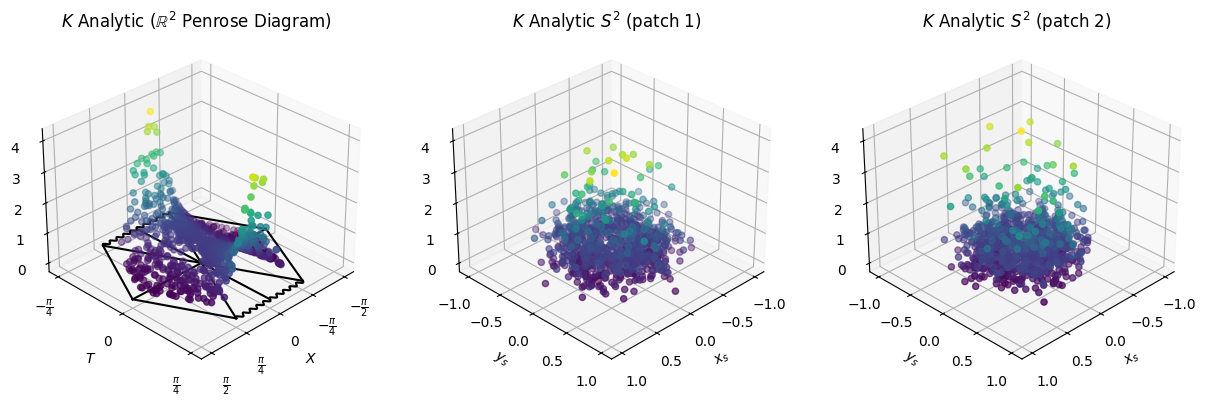

In [12]:
#### Analytic kretschmann
from geometry.schwarzschild import Analytic_Kretschmann

k_analytic = [Analytic_Kretschmann(test_samples[i]) for i in range(2)]

# Setup the plots
elevation_angle, azimuth_angle = 30, 45
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": "3d"})

axes_lim = 1.1
z_lim = 20
z_penrose = 1e-6  # tiny offset to avoid identical z values

# ---- R^2 plot with Penrose diagram ----
ax = axes[0]
# scatter the metric component on the base
ax.scatter(
    test_samples[0][:, 1],  # time coord (y-axis)
    test_samples[0][:, 0],  # space coord (x-axis)
    k_analytic[0][:],
    c=k_analytic[0][:],
    cmap="viridis",
)
# draw Penrose diagram on the tiny z plane
draw_penrose(ax)  # will need to internally use zs=z_penrose, zdir='z' for lines
ax.set_title(r"$K$ Analytic ($\mathbb{R}^2$ Penrose Diagram)")
ax.set_xlim(-axes_lim * np.pi / 2, axes_lim * np.pi / 2)
ax.set_ylim(-axes_lim * np.pi / 4, axes_lim * np.pi / 4)
# ax.set_zlim(-0.01, 0.01)  # tiny z range for Penrose diagram
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$T$")
# ax.view_init(elev=90, azim=-90)  # top-down to view the 2D diagram
ax.view_init(elev=elevation_angle, azim=azimuth_angle)

# ---- S^2 plots ----
for i in range(2):
    ax = axes[i + 1]
    ax.scatter(
        test_samples[i][:, 2],
        test_samples[i][:, 3],
        k_analytic[i][:],
        c=k_analytic[i][:],
        cmap="viridis",
    )
    ax.set_title(rf"$K$ Analytic $S^2$ (patch {i + 1})")
    ax.set_xlim(-axes_lim, axes_lim)
    ax.set_ylim(-axes_lim, axes_lim)
    ax.set_xlabel(r"$x_s$")
    ax.set_ylabel(r"$y_s$")
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

In [ ]:
#################################################################################
### TESTING ###
#################################################################################

In [13]:
# Tune kretschmann loss
from losses.schwarzschild import KretschmannLossSchwarzschild, WeightSchwarzschild

weighter = WeightSchwarzschild(loaded_model.config)
k_loss_p1 = KretschmannLossSchwarzschild(loaded_model.config, weighter)
k_loss_p2 = KretschmannLossSchwarzschild(loaded_model.config, weighter)

klv1 = k_loss_p1.compute(
    test_samples[0], predicted_metrics[0], loaded_model.patch_submodels[0]
)
klv2 = k_loss_p2.compute(
    test_samples[1], predicted_metrics[1], loaded_model.patch_submodels[1]
)
print(klv1.numpy(), klv2.numpy())

ImportError: cannot import name 'KretschmannLossSchwarzschild' from 'losses.schwarzschild' (/Users/tancredischettinigherardini/Code/ainstein_internal/losses/schwarzschild.py)

In [ ]:
# Tune einstein loss
from losses.base import EinsteinLoss

weighter = WeightSchwarzschild(loaded_model.config)
e_loss_p1 = EinsteinLoss(loaded_model.config, weighter)
e_loss_p2 = EinsteinLoss(loaded_model.config, weighter)

elv1 = e_loss_p1.compute(
    test_samples[0], predicted_metrics[0], loaded_model.patch_submodels[0]
)
elv2 = e_loss_p2.compute(
    test_samples[1], predicted_metrics[1], loaded_model.patch_submodels[1]
)
print(elv1.numpy(), elv2.numpy())

In [ ]:
# oloss
from losses.schwarzschild import OverlapLossSchwarzschild

o_loss = OverlapLossSchwarzschild(loaded_model.config, weighter)
olv = o_loss.compute(test_samples[0], predicted_metrics)

print(olv.numpy())

In [ ]:
########delete !
# Test coded metric etc
pts = np.array(
    [
        [0.05, np.pi / 3, 0.3, 0.7],
        [np.pi / 8.0, np.pi / 7.0, 0.3, 0.7],
        [0.05, -np.pi / 3, 0.3, 0.7],
        [-np.pi / 8.0, 0.07, 0.3, 0.7],
    ]
)

idx = 3
met = AnalyticMetric_R2S2(pts, identity=0, lorentzian=1, m=1.0)
# print(pts[idx])
# print(met[idx].numpy())
print(pts)
print(met.numpy())

In [ ]:
########delete !
# Test coded vielbein etc
from geometry.schwarzschild import AnalyticVielbein_R2S2

pts = np.array(
    [
        [0.05, np.pi / 3, 0.3, 0.7],
        [np.pi / 8.0, np.pi / 7.0, 0.3, 0.7],
        [0.05, -np.pi / 3, 0.3, 0.7],
        [-np.pi / 8.0, 0.07, 0.3, 0.7],
    ]
)
out = AnalyticVielbein_R2S2(pts)

idx = 0
print(pts)
print(out.numpy())

In [ ]:
########delete !
# test the L \eta L^T gives the metric
from helper_functions.helper_functions import cholesky_from_vec, cholesky_to_vec

idx = 2
mm = cholesky_from_vec(cholesky_to_vec(out[idx], lorentzian=True), lorentzian=True)
print(met[idx].numpy())
print(mm.numpy())
print(np.allclose(met[idx], mm))

In [ ]:
########delete !
# Test kretshamnn code
from geometry.schwarzschild import Analytic_Kretschmann

pts = np.array(
    [
        [0.05, np.pi / 3, 0.3, 0.7],
        [np.pi / 8.0, np.pi / 7.0, 0.3, 0.7],
        [0.09, -np.pi / 3, 0.3, 0.7],
        [-np.pi / 8.0, 0.07, 0.3, 0.7],
    ]
)
out = Analytic_Kretschmann(pts)

print(pts)
print(out.numpy())

In [ ]:
# Tune finite loss
from losses.base import FiniteLoss
from losses.schwarzschild import WeightSchwarzschild

weighter = WeightSchwarzschild(loaded_model.config)

# Create FiniteLoss instances for R2 and S2 submanifolds
finite_loss_R2_computer = FiniteLoss(
    loaded_model.config, (), weighter, dim=2, submanifold_is_R2=True
)

finite_loss_S2_computer = FiniteLoss(
    loaded_model.config, (), weighter, dim=2, submanifold_is_R2=False
)

# Compute finite losses for both patches
finite_losses_R2 = []
finite_losses_S2 = []

for patch_idx in range(loaded_model.n_patches):
    # Compute R2 finite loss
    flv_R2 = finite_loss_R2_computer.compute(
        test_samples[patch_idx], predicted_metrics[patch_idx]
    )
    finite_losses_R2.append(flv_R2.numpy())

    # Compute S2 finite loss
    flv_S2 = finite_loss_S2_computer.compute(
        test_samples[patch_idx], predicted_metrics[patch_idx]
    )
    finite_losses_S2.append(flv_S2.numpy())

# Print statistics
print("Finite Loss R2 (submanifold_is_R2=True):")
for i, flv in enumerate(finite_losses_R2):
    print(f"  Patch {i + 1}: {flv:.6e}")
print(f"  Average: {np.mean(finite_losses_R2):.6e}")
print(
    f"  Min: {np.min(finite_losses_R2):.6e}, Max: {np.max(finite_losses_R2):.6e}, Std: {np.std(finite_losses_R2):.6e}"
)

print("\nFinite Loss S2 (submanifold_is_R2=False):")
for i, flv in enumerate(finite_losses_S2):
    print(f"  Patch {i + 1}: {flv:.6e}")
print(f"  Average: {np.mean(finite_losses_S2):.6e}")
print(
    f"  Min: {np.min(finite_losses_S2):.6e}, Max: {np.max(finite_losses_S2):.6e}, Std: {np.std(finite_losses_S2):.6e}"
)